# 🧠 Real-Time Seizure Detection — Dual-Dataset Training
## CNN-GRU-Attention trained on CHB-MIT + SEINA → Saved as PyTorch

### Key Changes from v1:
- **Trains on both CHB-MIT and SEINA** (domain-robust generalization)
- **Patient-level splits** — 1 patient from each dataset held out for val and test
- **Domain-robust augmentation** applied during training
- **Saved as PyTorch `.pth`** via weight transfer

### Split Strategy:
| Set | CHB-MIT | SEINA |
|-----|---------|-------|
| Train | chb01–chb07 | PN03,PN05,PN06,PN07,PN09,PN10,PN12,PN13,PN14 |
| Val | chb08 | PN16 |
| Test | chb09 | PN17 |

In [1]:
# ============================================================
# CELL 1: Install & Import
# ============================================================

!pip install pyedflib mne pywavelets -q

import os
import re
import gc
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import defaultdict

import pyedflib
import mne
from scipy import signal
from scipy.signal import butter, filtfilt, resample

import tensorflow as tf
from tensorflow import keras
from keras import layers, Model, regularizers
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

print('✅ All libraries imported')
print(f'   TensorFlow: {tf.__version__}')
print(f'   PyTorch:    {torch.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'   GPU: {gpus[0].name}')
else:
    print('   Running on CPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 21.7 MB/s eta 0:00:0000:0100:01


2026-05-26 10:20:26.774664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779790827.054141      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779790827.135391      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779790827.798891      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779790827.798953      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779790827.798958      57 computation_placer.cc:177] computation placer alr

✅ All libraries imported
   TensorFlow: 2.19.0
   PyTorch:    2.10.0+cpu
   Running on CPU


2026-05-26 10:21:02.622954: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# ============================================================
# CELL 2: Paths & Split Configuration
# ============================================================

# ── Dataset paths ────────────────────────────────────────────
CHB_MIT_PATH = '/kaggle/input/datasets/abhishekinnvonix/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0'
SEINA_PATH   = '/kaggle/input/datasets/abhishekinnvonix/epilepsy-seizure-dataset-seina-scalp-complete/siena-scalp-eeg-database-1.0.0'
OUTPUT_DIR   = '/kaggle/working/'

os.makedirs(os.path.join(OUTPUT_DIR, 'images'), exist_ok=True)

# ── Signal config ─────────────────────────────────────────────
N_CHANNELS   = 18
TARGET_FS    = 256      # Hz — resample SEINA (512 Hz) to this
WINDOW_SEC   = 4        # seconds
OVERLAP      = 0.5      # 50%
WINDOW_SAMP  = WINDOW_SEC * TARGET_FS          # 1024
STEP_SAMP    = int(WINDOW_SAMP * (1 - OVERLAP)) # 512

# ── Patient-level split ───────────────────────────────────────
CHB_TRAIN = ['chb01','chb02','chb03','chb05','chb06','chb07','chb08','chb14','chb15','chb16','chb20','chb23']
CHB_VAL   = ['chb09','chb17','chb18']   # 3 patient held out for validation
CHB_TEST  = ['chb10','chb19','chb24']   # 3 patient held out for test

SEINA_TRAIN = ['PN01','PN03','PN05','PN06','PN07','PN09','PN10','PN12','PN13']
SEINA_VAL   = ['PN14','PN15']   # 2 patient held out for validation
SEINA_TEST  = ['PN16','PN02']   # 2 patient held out for test

print('='*60)
print('📋 DUAL-DATASET TRAINING CONFIGURATION')
print('='*60)
print(f'\nCHB-MIT:')
print(f'  Train: {CHB_TRAIN}')
print(f'  Val  : {CHB_VAL}')
print(f'  Test : {CHB_TEST}')
print(f'\nSEINA:')
print(f'  Train: {SEINA_TRAIN}')
print(f'  Val  : {SEINA_VAL}')
print(f'  Test : {SEINA_TEST}')
print(f'\nSignal config:')
print(f'  Window: {WINDOW_SEC}s ({WINDOW_SAMP} samples @ {TARGET_FS} Hz)')
print(f'  Overlap: {OVERLAP*100}%  |  Channels: {N_CHANNELS}')

📋 DUAL-DATASET TRAINING CONFIGURATION

CHB-MIT:
  Train: ['chb01', 'chb02', 'chb03', 'chb05', 'chb06', 'chb07', 'chb08', 'chb14', 'chb15', 'chb16', 'chb20', 'chb23']
  Val  : ['chb09', 'chb17', 'chb18']
  Test : ['chb10', 'chb19', 'chb24']

SEINA:
  Train: ['PN01', 'PN03', 'PN05', 'PN06', 'PN07', 'PN09', 'PN10', 'PN12', 'PN13']
  Val  : ['PN14', 'PN15']
  Test : ['PN16', 'PN02']

Signal config:
  Window: 4s (1024 samples @ 256 Hz)
  Overlap: 50.0%  |  Channels: 18


In [3]:
# ============================================================
# CELL 3: Parse CHB-MIT Annotations
# ============================================================

def parse_chbmit_summary(summary_path):
    seizure_info = {}
    with open(summary_path, 'r') as f:
        content = f.read()
    for block in content.split('File Name:')[1:]:
        lines = block.strip().split('\n')
        filename = lines[0].strip()
        seizure_times = []
        start_time = None
        for line in lines:
            if 'Seizure' in line and 'Start Time' in line:
                try:
                    start_time = int(line.split(':')[-1].replace('seconds','').strip())
                except: pass
            if 'Seizure' in line and 'End Time' in line:
                try:
                    end_time = int(line.split(':')[-1].replace('seconds','').strip())
                    if start_time is not None:
                        seizure_times.append((start_time, end_time))
                        start_time = None
                except: pass
        if seizure_times:
            seizure_info[filename] = seizure_times
    return seizure_info

print('Parsing CHB-MIT annotations...')
chb_annotations = {}
for patient in sorted(os.listdir(CHB_MIT_PATH)):
    if not patient.startswith('chb'): continue
    summary = os.path.join(CHB_MIT_PATH, patient, f'{patient}-summary.txt')
    if os.path.exists(summary):
        info = parse_chbmit_summary(summary)
        if info:
            chb_annotations[patient] = info
            n = sum(len(v) for v in info.values())
            print(f'  ✓ {patient}: {len(info)} files, {n} seizures')

print(f'\nTotal CHB-MIT patients with seizures: {len(chb_annotations)}')

Parsing CHB-MIT annotations...
  ✓ chb01: 7 files, 7 seizures
  ✓ chb02: 3 files, 3 seizures
  ✓ chb03: 7 files, 7 seizures
  ✓ chb04: 3 files, 4 seizures
  ✓ chb05: 5 files, 5 seizures
  ✓ chb06: 7 files, 10 seizures
  ✓ chb07: 3 files, 3 seizures
  ✓ chb08: 5 files, 5 seizures
  ✓ chb09: 3 files, 4 seizures
  ✓ chb10: 7 files, 7 seizures
  ✓ chb11: 3 files, 3 seizures
  ✓ chb12: 13 files, 40 seizures
  ✓ chb13: 8 files, 12 seizures
  ✓ chb14: 7 files, 8 seizures
  ✓ chb15: 14 files, 20 seizures
  ✓ chb16: 6 files, 10 seizures
  ✓ chb17: 3 files, 3 seizures
  ✓ chb18: 6 files, 6 seizures
  ✓ chb19: 3 files, 3 seizures
  ✓ chb20: 6 files, 8 seizures
  ✓ chb21: 4 files, 4 seizures
  ✓ chb22: 3 files, 3 seizures
  ✓ chb23: 3 files, 7 seizures
  ✓ chb24: 12 files, 16 seizures

Total CHB-MIT patients with seizures: 24


In [4]:
# ============================================================
# CELL 4: Parse SEINA Annotations
# ============================================================

def time_to_seconds(time_str):
    time_str = time_str.strip()
    m = re.search(r'(\d+)[\.:]+(\d+)[\.:]+(\d+)', time_str)
    if m:
        h, mn, s = int(m.group(1)), int(m.group(2)), int(m.group(3))
        return h * 3600 + mn * 60 + s
    return 0

def parse_seina_annotations(base_path):
    annotations = {}
    patient_dirs = sorted([d for d in os.listdir(base_path)
                           if os.path.isdir(os.path.join(base_path, d))
                           and d.startswith('PN')])
    for patient in patient_dirs:
        seizure_file = os.path.join(base_path, patient, f'Seizures-list-{patient}.txt')
        if not os.path.exists(seizure_file): continue
        with open(seizure_file, 'r') as f:
            content = f.read()
        seizure_info = {}
        for block in content.split('Seizure n')[1:]:
            lines = block.strip().split('\n')
            filename = start_sec = end_sec = None
            for line in lines:
                if 'File name:' in line:
                    filename = line.split('File name:')[1].strip() + '.edf'
                    filename = filename.replace('.edf.edf', '.edf')
                elif 'Seizure start time:' in line:
                    start_sec = time_to_seconds(line.split('Seizure start time:')[1])
                elif 'Seizure end time:' in line:
                    end_sec = time_to_seconds(line.split('Seizure end time:')[1])
            if filename and start_sec is not None and end_sec is not None:
                seizure_info.setdefault(filename, []).append((start_sec, end_sec))
        if seizure_info:
            annotations[patient] = seizure_info
            n = sum(len(v) for v in seizure_info.values())
            print(f'  ✓ {patient}: {len(seizure_info)} files, {n} seizures')
    return annotations

print('Parsing SEINA annotations...')
seina_annotations = parse_seina_annotations(SEINA_PATH)
print(f'\nTotal SEINA patients with seizures: {len(seina_annotations)}')

Parsing SEINA annotations...
  ✓ PN00: 5 files, 5 seizures
  ✓ PN03: 2 files, 2 seizures
  ✓ PN05: 3 files, 3 seizures
  ✓ PN06: 5 files, 5 seizures
  ✓ PN07: 1 files, 1 seizures
  ✓ PN09: 3 files, 3 seizures
  ✓ PN10: 6 files, 10 seizures
  ✓ PN11: 1 files, 1 seizures
  ✓ PN12: 3 files, 4 seizures
  ✓ PN13: 3 files, 3 seizures
  ✓ PN14: 4 files, 4 seizures
  ✓ PN16: 2 files, 2 seizures
  ✓ PN17: 2 files, 2 seizures

Total SEINA patients with seizures: 13


In [5]:
# ============================================================
# CELL 5: Preprocessing Pipeline (UPDATED)
# Changes:
#   - Added is_artifact_window() for per-window artifact rejection
#   - Added time_warp() augmentation
#   - Added channel_permutation() augmentation
#   - Added gaussian_mixture_noise() augmentation
#   - Added pre-ictal buffer support via PRE_ICTAL_BUFFER
# ============================================================

PRE_ICTAL_BUFFER = 5   # seconds to exclude before seizure onset

class EEGPreprocessor:
    def __init__(self, sampling_rate=256, low_freq=0.5, high_freq=100, notch_freq=60):
        self.fs          = sampling_rate
        self.low_freq    = low_freq
        self.high_freq   = high_freq
        self.notch_freq  = notch_freq

    # ── Core filters ─────────────────────────────────────────

    def bandpass_filter(self, data, order=4):
        nyquist = self.fs / 2
        low     = self.low_freq  / nyquist
        high    = min(self.high_freq / nyquist, 0.99)
        b, a    = butter(order, [low, high], btype='band')
        fn      = filtfilt
        if data.ndim == 1:
            return fn(b, a, data)
        return np.array([fn(b, a, ch) for ch in data])

    def notch_filter(self, data, Q=30):
        nyquist = self.fs / 2
        freq    = self.notch_freq / nyquist
        b, a    = signal.iirnotch(freq, Q)
        fn      = filtfilt
        if data.ndim == 1:
            return fn(b, a, data)
        return np.array([fn(b, a, ch) for ch in data])

    def normalize(self, data):
        if data.ndim == 1:
            return (data - np.mean(data)) / (np.std(data) + 1e-8)
        return np.array([(ch - np.mean(ch)) / (np.std(ch) + 1e-8) for ch in data])

    def remove_artifacts(self, data, threshold=5):
        """Hard clip to ±threshold σ (applied after z-score)."""
        return np.clip(data, -threshold, threshold)

    # ── Artifact window detection ─────────────────────────────

    def is_artifact_window(self, window, ptp_threshold=8.0, bad_ch_ratio=0.3):
        """
        Return True if this window is likely a bad/artifact window.
        Checks peak-to-peak amplitude per channel after z-score normalization.

        Parameters
        ----------
        window        : np.ndarray  (n_channels, n_samples)  — already preprocessed
        ptp_threshold : float       — peak-to-peak limit in normalized units
        bad_ch_ratio  : float       — fraction of channels that must exceed threshold
                                      before window is flagged
        """
        ptp         = np.ptp(window, axis=1)          # shape (n_channels,)
        n_bad       = np.sum(ptp > ptp_threshold)
        return n_bad > (window.shape[0] * bad_ch_ratio)

    # ── Augmentation helpers ──────────────────────────────────

    def _time_warp(self, data):
        """Stretch or compress the temporal axis by ±10%, then crop/pad."""
        factor  = np.random.uniform(0.9, 1.1)
        n_orig  = data.shape[1]
        n_new   = int(n_orig * factor)
        warped  = np.array([resample(data[i], n_new) for i in range(data.shape[0])])
        if warped.shape[1] > n_orig:
            start  = np.random.randint(0, warped.shape[1] - n_orig)
            warped = warped[:, start:start + n_orig]
        elif warped.shape[1] < n_orig:
            pad    = np.zeros((warped.shape[0], n_orig - warped.shape[1]))
            warped = np.concatenate([warped, pad], axis=1)
        return warped

    def _channel_permutation(self, data):
        """Swap two randomly chosen channels."""
        i, j        = np.random.choice(data.shape[0], 2, replace=False)
        data        = data.copy()
        data[[i, j]] = data[[j, i]]
        return data

    def _gaussian_mixture_noise(self, data):
        """Add Gaussian noise with a randomly selected noise floor."""
        noise_level = np.random.choice([0.01, 0.05, 0.10])
        return data + np.random.randn(*data.shape) * noise_level

    # ── Main pipeline ─────────────────────────────────────────

    def preprocess(self, data, augment=False):
        """
        Full preprocessing pipeline.

        Order:
          1. Bandpass filter  (0.5–100 Hz, 4th-order Butterworth, zero-phase)
          2. Notch filter     (60 Hz power-line removal)
          3. Z-score normalize per channel
          4. Artifact clip    (±5 σ)
          5. [train only] Domain-robust + morphological augmentation
        """
        data = self.bandpass_filter(data)
        data = self.notch_filter(data)
        data = self.normalize(data)
        data = self.remove_artifacts(data)

        if augment:
            # ── Domain-robust augmentations (bridge CHB-MIT ↔ SEINA gap) ──
            data = data * np.random.uniform(0.85, 1.15)              # amplitude jitter
            data = data + np.random.randn(*data.shape) * 0.02        # per-sample channel noise
            data = data + np.random.randn(data.shape[0], 1) * 0.05   # per-channel DC offset

            if np.random.rand() < 0.3:                               # random channel dropout
                ch        = np.random.randint(data.shape[0])
                data[ch]  = 0.0

            # ── Morphological augmentations (improve ictal diversity) ──
            if np.random.rand() < 0.4:
                data = self._time_warp(data)                         # temporal stretch/compress

            if np.random.rand() < 0.2:
                data = self._channel_permutation(data)               # swap two channels

            if np.random.rand() < 0.3:
                data = self._gaussian_mixture_noise(data)            # varied noise floor

            data = np.clip(data, -5, 5)                              # final safety clip

        return data


preprocessor = EEGPreprocessor(sampling_rate=TARGET_FS)
print('✅ Preprocessor ready')
print(f'   Pre-ictal buffer : {PRE_ICTAL_BUFFER}s')
print(f'   Augmentations    : amplitude jitter | channel noise | DC offset | '
      f'channel dropout | time warp | channel permutation | gaussian noise')

✅ Preprocessor ready
   Pre-ictal buffer : 5s
   Augmentations    : amplitude jitter | channel noise | DC offset | channel dropout | time warp | channel permutation | gaussian noise


In [6]:
# ============================================================
# CELL 6: EDF Loaders
# ============================================================

def load_edf_chbmit(file_path, n_channels=18):
    """Load CHB-MIT EDF — returns (signals, fs) at original rate."""
    try:
        f = pyedflib.EdfReader(file_path)
        n_avail = f.signals_in_file
        n_ch    = min(n_channels, n_avail)
        fs      = int(f.getSampleFrequency(0))
        n_samp  = f.getNSamples()[0]
        sigs    = np.zeros((n_ch, n_samp))
        for i in range(n_ch):
            sigs[i] = f.readSignal(i)
        f.close()
        return sigs, fs
    except:
        return None, None

def load_edf_seina(file_path, n_channels=18, target_fs=256):
    """Load SEINA EDF — resamples 512→256 Hz automatically."""
    try:
        f = pyedflib.EdfReader(file_path)
        n_avail = f.signals_in_file
        n_ch    = min(n_channels, n_avail)
        orig_fs = int(f.getSampleFrequency(0))
        n_samp  = f.getNSamples()[0]
        sigs    = np.zeros((n_ch, n_samp))
        for i in range(n_ch):
            sigs[i] = f.readSignal(i)
        f.close()
        if orig_fs != target_fs:
            n_target = int(sigs.shape[1] * target_fs / orig_fs)
            sigs = np.array([resample(sigs[i], n_target) for i in range(sigs.shape[0])])
        return sigs, target_fs
    except:
        return None, None

print('✅ EDF loaders ready')

✅ EDF loaders ready


In [7]:
# ============================================================
# CELL 7: Window Extraction (UPDATED)
# Changes:
#   - label_window() now returns -1 for pre-ictal buffer windows
#   - extract_windows() skips pre-ictal (-1) windows entirely
#   - extract_windows() rejects artifact-contaminated normal windows
#   - Added test_mode flag: uses non-overlapping windows for honest evaluation
# ============================================================

def label_window(window_start_sec, window_end_sec, seizure_times, window_sec):
    """
    Label a window given its time boundaries and the seizure annotation.

    Returns
    -------
    1  : ictal  — ≥50% of window overlaps a seizure
    -1 : ambiguous — window falls inside the pre-ictal buffer
         (PRE_ICTAL_BUFFER seconds before seizure onset); skip this window
    0  : normal — no overlap and outside the pre-ictal buffer
    """
    for sz_start, sz_end in seizure_times:

        # ── Pre-ictal buffer check ────────────────────────────
        # Exclude the PRE_ICTAL_BUFFER seconds immediately before onset.
        # These transitional windows confuse the normal/ictal boundary.
        buffer_start = sz_start - PRE_ICTAL_BUFFER
        if buffer_start <= window_start_sec < sz_start:
            return -1   # ambiguous — skip

        # ── Ictal overlap check ───────────────────────────────
        if window_start_sec < sz_end and window_end_sec > sz_start:
            ov_start = max(window_start_sec, sz_start)
            ov_end   = min(window_end_sec,   sz_end)
            if (ov_end - ov_start) / window_sec >= 0.5:
                return 1  # ictal

    return 0  # normal


def extract_windows(signals, fs, seizure_times, augment=False, test_mode=False):
    """
    Slide windows over preprocessed signals and return labelled windows.

    Parameters
    ----------
    signals       : np.ndarray  (n_channels, n_samples)
    fs            : int         sampling rate in Hz
    seizure_times : list of (start_sec, end_sec) tuples
    augment       : bool        apply augmentation (train only)
    test_mode     : bool        if True, use non-overlapping stride (no data leakage)
                                if False, use 50% overlap stride (train/val)

    Returns
    -------
    sz_wins  : list of np.ndarray  ictal windows
    nm_wins  : list of np.ndarray  normal windows
    skipped  : int                 number of windows skipped (pre-ictal or artifact)
    """
    proc   = EEGPreprocessor(sampling_rate=fs)
    sigs   = proc.preprocess(signals, augment=augment)

    n_samp = sigs.shape[1]

    # Non-overlapping stride for test set — avoids correlated test samples
    # that inflate recall when a seizure spans multiple windows
    step   = WINDOW_SAMP if test_mode else STEP_SAMP

    sz_wins, nm_wins = [], []
    skipped          = 0

    for start in range(0, n_samp - WINDOW_SAMP, step):
        end = start + WINDOW_SAMP
        win = sigs[:, start:end]
        if win.shape[1] != WINDOW_SAMP:
            continue

        lbl = label_window(start / fs, end / fs, seizure_times, WINDOW_SEC)

        # Skip pre-ictal buffer windows entirely
        if lbl == -1:
            skipped += 1
            continue

        if lbl == 1:
            sz_wins.append(win.astype(np.float32))

        else:
            # Reject artifact-contaminated normal windows.
            # We do NOT reject artifact ictal windows — those still
            # need to be learned (and are rare enough to matter).
            if proc.is_artifact_window(win):
                skipped += 1
                continue
            nm_wins.append(win.astype(np.float32))

    return sz_wins, nm_wins, skipped


print('✅ Window extraction ready')
print(f'   Train/val stride : {STEP_SAMP} samples (50% overlap)')
print(f'   Test stride      : {WINDOW_SAMP} samples (no overlap)')
print(f'   Pre-ictal buffer : {PRE_ICTAL_BUFFER}s excluded')
print(f'   Artifact reject  : enabled for normal windows (ptp > 8σ on >30% channels)')

✅ Window extraction ready
   Train/val stride : 512 samples (50% overlap)
   Test stride      : 1024 samples (no overlap)
   Pre-ictal buffer : 5s excluded
   Artifact reject  : enabled for normal windows (ptp > 8σ on >30% channels)


In [8]:
# ============================================================
# CELL 8: Build Dataset for a Given Patient Split (UPDATED)
# Changes:
#   - Handles new 3-return-value extract_windows() (sz, nm, skipped)
#   - Passes test_mode=True when split_name == 'test'
#   - Reports skipped windows in summary
# ============================================================

def build_split(chb_patients, seina_patients,
                chb_annotations, seina_annotations,
                normal_ratio=2, normal_sample_rate=20,
                augment=False, split_name='train'):
    """
    Load, window, and balance EEG data from CHB-MIT + SEINA patients.

    Parameters
    ----------
    chb_patients        : list of str   CHB-MIT patient IDs to include
    seina_patients      : list of str   SEINA patient IDs to include
    chb_annotations     : dict          parsed CHB-MIT seizure annotations
    seina_annotations   : dict          parsed SEINA seizure annotations
    normal_ratio        : int           max normal windows = seizure_count × ratio
    normal_sample_rate  : int           keep 1-in-N normal windows (memory saving)
    augment             : bool          apply augmentation (train only)
    split_name          : str           'train', 'val', or 'test'

    Returns
    -------
    X : np.ndarray  (n_samples, WINDOW_SAMP, N_CHANNELS)
    y : np.ndarray  (n_samples,)  binary labels
    """
    # Use non-overlapping windows for test to avoid correlated samples
    is_test       = (split_name == 'test')

    all_seizure, all_normal = [], []
    normal_ctr              = 0
    total_skipped           = 0

    print(f'\n── {split_name.upper()} SET {"(non-overlapping windows)" if is_test else "(50% overlap)"} ─────')

    # ── CHB-MIT ──────────────────────────────────────────────
    print('  [CHB-MIT]')
    for patient in chb_patients:
        if patient not in chb_annotations:
            continue
        p_sz, p_nm, p_skip = 0, 0, 0
        for filename, seizure_times in chb_annotations[patient].items():
            fpath = os.path.join(CHB_MIT_PATH, patient, filename)
            if not os.path.exists(fpath):
                continue
            try:
                sigs, fs = load_edf_chbmit(fpath, n_channels=N_CHANNELS)
                if sigs is None:
                    continue
                sz_w, nm_w, skipped = extract_windows(
                    sigs, fs, seizure_times,
                    augment=augment,
                    test_mode=is_test
                )
                all_seizure.extend(sz_w)
                p_sz   += len(sz_w)
                p_skip += skipped
                for w in nm_w:
                    normal_ctr += 1
                    if normal_ctr % normal_sample_rate == 0:
                        all_normal.append(w)
                        p_nm += 1
                del sigs
                gc.collect()
            except Exception as e:
                continue
        print(f'    ✓ {patient}: {p_sz} seizure | {p_nm} normal | {p_skip} skipped')
        total_skipped += p_skip

    # ── SEINA ────────────────────────────────────────────────
    print('  [SEINA]')
    for patient in seina_patients:
        if patient not in seina_annotations:
            continue
        p_sz, p_nm, p_skip = 0, 0, 0
        for filename, seizure_times in seina_annotations[patient].items():
            fpath = os.path.join(SEINA_PATH, patient, filename)
            if not os.path.exists(fpath):
                continue
            try:
                sigs, fs = load_edf_seina(fpath, n_channels=N_CHANNELS, target_fs=TARGET_FS)
                if sigs is None:
                    continue
                # Pad channels if SEINA has fewer than N_CHANNELS
                if sigs.shape[0] < N_CHANNELS:
                    pad  = np.zeros((N_CHANNELS - sigs.shape[0], sigs.shape[1]))
                    sigs = np.concatenate([sigs, pad], axis=0)
                sz_w, nm_w, skipped = extract_windows(
                    sigs, fs, seizure_times,
                    augment=augment,
                    test_mode=is_test
                )
                all_seizure.extend(sz_w)
                p_sz   += len(sz_w)
                p_skip += skipped
                for w in nm_w:
                    normal_ctr += 1
                    if normal_ctr % normal_sample_rate == 0:
                        all_normal.append(w)
                        p_nm += 1
                del sigs
                gc.collect()
            except Exception as e:
                continue
        print(f'    ✓ {patient}: {p_sz} seizure | {p_nm} normal | {p_skip} skipped')
        total_skipped += p_skip

    print(f'\n  Total windows skipped (pre-ictal + artifact): {total_skipped}')

    # ── Balance ──────────────────────────────────────────────
    n_sz = len(all_seizure)
    n_nm = min(len(all_normal), n_sz * normal_ratio)

    if n_sz == 0:
        raise ValueError(f'No seizure windows found for {split_name} split. '
                         f'Check patient lists and annotation paths.')
    if n_nm == 0:
        raise ValueError(f'No normal windows found for {split_name} split.')

    np.random.seed(42)
    nm_idx = np.random.choice(len(all_normal), n_nm, replace=False)

    X_sz = np.array(all_seizure, dtype=np.float32)
    X_nm = np.array([all_normal[i] for i in nm_idx], dtype=np.float32)
    del all_seizure, all_normal
    gc.collect()

    X = np.concatenate([X_sz, X_nm], axis=0)
    y = np.concatenate([np.ones(len(X_sz)), np.zeros(len(X_nm))])
    del X_sz, X_nm
    gc.collect()

    # Shuffle
    idx  = np.random.permutation(len(X))
    X, y = X[idx], y[idx]

    # Reshape: (samples, channels, time) → (samples, time, channels)
    X = np.transpose(X, (0, 2, 1))

    ratio = (len(y) - np.sum(y)) / np.sum(y) if np.sum(y) > 0 else 0
    print(f'  Seizure  : {int(np.sum(y))}')
    print(f'  Normal   : {int(len(y) - np.sum(y))}')
    print(f'  Ratio    : 1 : {ratio:.1f}')
    print(f'  Shape    : {X.shape}')
    print(f'  Memory   : {X.nbytes / 1024 / 1024:.1f} MB')
    return X, y

In [9]:
# ============================================================
# CELL 9: Load All Three Splits
# ============================================================

print('='*60)
print('📦 BUILDING DUAL-DATASET SPLITS')
print('='*60)

# Training set — with augmentation
X_train, y_train = build_split(
    CHB_TRAIN, SEINA_TRAIN,
    chb_annotations, seina_annotations,
    normal_ratio=2, normal_sample_rate=20,
    augment=True, split_name='train'
)

# Validation set — no augmentation
X_val, y_val = build_split(
    CHB_VAL, SEINA_VAL,
    chb_annotations, seina_annotations,
    normal_ratio=2, normal_sample_rate=10,
    augment=False, split_name='val'
)

# Test set — no augmentation
X_test, y_test = build_split(
    CHB_TEST, SEINA_TEST,
    chb_annotations, seina_annotations,
    normal_ratio=2, normal_sample_rate=10,
    augment=False, split_name='test'
)

print('\n' + '='*60)
print('✅ All splits ready!')
print('='*60)
print(f'  Train : {X_train.shape}')
print(f'  Val   : {X_val.shape}')
print(f'  Test  : {X_test.shape}')

📦 BUILDING DUAL-DATASET SPLITS

── TRAIN SET (50% overlap) ─────
  [CHB-MIT]
    ✓ chb01: 219 seizure | 525 normal | 1229 skipped
    ✓ chb02: 85 seizure | 169 normal | 607 skipped
    ✓ chb03: 199 seizure | 504 normal | 2308 skipped
    ✓ chb05: 276 seizure | 415 normal | 410 skipped
    ✓ chb06: 70 seizure | 1840 normal | 9725 skipped
    ✓ chb07: 161 seizure | 574 normal | 4615 skipped
    ✓ chb08: 457 seizure | 357 normal | 1400 skipped
    ✓ chb14: 79 seizure | 596 normal | 576 skipped
    ✓ chb15: 987 seizure | 1055 normal | 3114 skipped
    ✓ chb16: 39 seizure | 386 normal | 3030 skipped
    ✓ chb20: 143 seizure | 449 normal | 886 skipped
    ✓ chb23: 208 seizure | 647 normal | 2974 skipped
  [SEINA]
    ✓ PN03: 121 seizure | 2034 normal | 2799 skipped
    ✓ PN05: 0 seizure | 429 normal | 2270 skipped
    ✓ PN06: 0 seizure | 304 normal | 1022 skipped
    ✓ PN07: 30 seizure | 747 normal | 756 skipped
    ✓ PN09: 0 seizure | 468 normal | 2951 skipped
    ✓ PN10: 0 seizure | 1470 n

In [10]:
# ============================================================
# CELL 10: Build Keras Model
# ============================================================

def build_seizure_model(input_shape):
    inputs = layers.Input(shape=input_shape, name='eeg_input')

    # CNN
    x = layers.Conv1D(32, kernel_size=7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # GRU
    x = layers.GRU(128, return_sequences=True, dropout=0.3)(x)
    x = layers.GRU(64,  return_sequences=True, dropout=0.3)(x)

    # Attention
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    attention = layers.LayerNormalization()(attention + x)

    # Pooling
    avg_pool = layers.GlobalAveragePooling1D()(attention)
    max_pool = layers.GlobalMaxPooling1D()(attention)
    x = layers.Concatenate()([avg_pool, max_pool])

    # Classifier
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='seizure_output')(x)

    return Model(inputs=inputs, outputs=outputs, name='CNN_GRU_Attention_SeizureDetector')

input_shape = (X_train.shape[1], X_train.shape[2])  # (1024, 18)
model = build_seizure_model(input_shape)
model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "CNN_GRU_Attention_SeizureDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 1024, 18)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1024, 32)  │      4,064 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 512, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 32)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 512, 64)   │     10,304 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 64)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 128)  │     24,704 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 128, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 128)  │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128, 128)  │     99,072 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 128, 64)   │     37,248 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     33,216 │ gru_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 220,257 (860.38 KB)

 Trainable params: 219,681 (858.13 KB)

 Non-trainable params: 576 (2.25 KB)


Total parameters: 220,257


In [11]:
# ============================================================
# CELL 11: Compile & Train (UPDATED)
# Changes:
#   - Replaced binary_crossentropy with focal_loss
#   - focal_loss(gamma=2.0, alpha=0.75) down-weights easy negatives
#     and up-weights the rare seizure class simultaneously
#   - All callbacks unchanged
# ============================================================

import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal loss for binary classification.

    Parameters
    ----------
    gamma : float   focusing parameter — higher values down-weight easy examples more.
                    gamma=0 reduces to standard binary cross-entropy.
                    gamma=2 is the value used in the original Lin et al. (2017) paper.
    alpha : float   class balance weight for the positive (seizure) class.
                    alpha > 0.5 gives MORE weight to seizure windows.
                    Recommended: set alpha = n_normal / (n_normal + n_seizure)
                    for your training set, or use 0.75 as a reasonable starting point.

    Returns
    -------
    Keras-compatible loss function.
    """
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true  = tf.cast(y_true, tf.float32)

        # Standard binary cross-entropy per sample
        bce     = -(y_true * tf.math.log(y_pred)
                    + (1.0 - y_true) * tf.math.log(1.0 - y_pred))

        # p_t: probability of the ground-truth class
        p_t     = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)

        # alpha_t: class-specific weight
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)

        # Focal weight: (1 - p_t)^gamma suppresses easy examples
        focal_w = alpha_t * tf.pow(1.0 - p_t, gamma)

        return tf.reduce_mean(focal_w * bce)

    loss_fn.__name__ = f'focal_loss_g{gamma}_a{alpha}'
    return loss_fn


# ── Compile ───────────────────────────────────────────────────

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# ── Callbacks ─────────────────────────────────────────────────

callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=10, mode='max',
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_seizure_model.keras'),
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    )
]

# ── Class weights ─────────────────────────────────────────────
# Focal loss already handles imbalance via alpha, but class_weight
# provides an additional multiplicative signal at the gradient level.
# Keep it mild (ratio capped at 5) to avoid over-penalizing normal class.

n_sz         = int(np.sum(y_train))
n_nm         = int(len(y_train) - n_sz)
raw_ratio    = n_nm / n_sz
capped_ratio = min(raw_ratio, 5.0)       # cap to avoid exploding gradients
class_weights = {0: 1.0, 1: capped_ratio}

print('='*60)
print('🔧 TRAINING CONFIGURATION')
print('='*60)
print(f'  Loss            : Focal (γ=2.0, α=0.75)')
print(f'  Optimizer       : Adam  (lr=0.001)')
print(f'  Epochs          : 50 (early stop patience=10 on val_AUC)')
print(f'  Batch size      : 32')
print(f'  Class weight    : Normal=1.0 | Seizure={capped_ratio:.2f} (raw={raw_ratio:.2f}, capped at 5)')
print(f'  Train samples   : {len(y_train)} (seizure={n_sz}, normal={n_nm})')
print('='*60)

print('\n🚀 TRAINING STARTED...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ TRAINING COMPLETE')
print(f'  Epochs run      : {len(history.history["loss"])}')
print(f'  Best Val AUC    : {max(history.history["val_auc"]):.4f}')
print(f'  Best Val Loss   : {min(history.history["val_loss"]):.4f}')

🔧 TRAINING CONFIGURATION
  Loss            : Focal (γ=2.0, α=0.75)
  Optimizer       : Adam  (lr=0.001)
  Epochs          : 50 (early stop patience=10 on val_AUC)
  Batch size      : 32
  Class weight    : Normal=1.0 | Seizure=2.00 (raw=2.00, capped at 5)
  Train samples   : 9222 (seizure=3074, normal=6148)

🚀 TRAINING STARTED...
Epoch 1/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6439 - auc: 0.7797 - loss: 0.7525 - precision: 0.4836 - recall: 0.7985
Epoch 1: val_auc improved from -inf to 0.87608, saving model to /kaggle/working/best_seizure_model.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 119s 368ms/step - accuracy: 0.6442 - auc: 0.7799 - loss: 0.7518 - precision: 0.4838 - recall: 0.7985 - val_accuracy: 0.8828 - val_auc: 0.8761 - val_loss: 0.2328 - val_precision: 0.9764 - val_recall: 0.6644 - learning_rate: 0.0010
Epoch 2/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8175 - auc: 0.9136 - loss: 0.1806 - precision: 0.6875 - recall: 0.8455
Epoch 2: val_auc improved 

In [12]:
# ============================================================
# CELL 12: Evaluate on Test Set (UPDATED)
# Changes:
#   - Computes metrics at three thresholds:
#       (a) default 0.5
#       (b) Youden's J optimum (maximizes sensitivity + specificity)
#       (c) Clinical threshold (recall ≥ 0.90, then maximize precision)
#   - Prints full comparison table
#   - Sets BEST_THRESHOLD for use in Cell 13 visualization
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    precision_recall_curve
)

print('=' * 60)
print('📊 TEST SET EVALUATION')
print('=' * 60)

# ── Get raw probabilities ─────────────────────────────────────
y_pred_proba = model.predict(X_test, verbose=0).flatten()

# ── ROC & PR curves ──────────────────────────────────────────
fpr, tpr, roc_thresholds     = roc_curve(y_test, y_pred_proba)
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# ── Threshold selection ───────────────────────────────────────

# (a) Default
THRESHOLD_DEFAULT  = 0.5

# (b) Youden's J = argmax(TPR - FPR) — balances sensitivity & specificity
youdens_j          = tpr - fpr
best_idx_youden    = np.argmax(youdens_j)
THRESHOLD_YOUDEN   = float(roc_thresholds[best_idx_youden])

# (c) Clinical: recall >= 0.90, then pick highest precision
TARGET_RECALL      = 0.90
valid_mask         = recalls[:-1] >= TARGET_RECALL
if valid_mask.any():
    best_idx_clin  = np.where(valid_mask)[0][np.argmax(precisions[:-1][valid_mask])]
    THRESHOLD_CLIN = float(pr_thresholds[best_idx_clin])
else:
    # Fallback: use Youden if recall target is unachievable
    THRESHOLD_CLIN = THRESHOLD_YOUDEN
    print(f'  ⚠️  Recall ≥ {TARGET_RECALL} not achievable — using Youden threshold as clinical fallback')

# ── Helper: compute all metrics at a given threshold ──────────
def metrics_at_threshold(y_true, y_proba, threshold, label=''):
    y_pred  = (y_proba > threshold).astype(int)
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, zero_division=0)
    rec     = recall_score(y_true, y_pred, zero_division=0)
    f1      = f1_score(y_true, y_pred, zero_division=0)
    cm      = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec    = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return dict(label=label, threshold=threshold,
                accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1,
                tp=tp, tn=tn, fp=fp, fn=fn, cm=cm)

r_default = metrics_at_threshold(y_test, y_pred_proba, THRESHOLD_DEFAULT,  'Default (0.5)')
r_youden  = metrics_at_threshold(y_test, y_pred_proba, THRESHOLD_YOUDEN,   "Youden's J")
r_clin    = metrics_at_threshold(y_test, y_pred_proba, THRESHOLD_CLIN,     'Clinical (recall≥0.90)')

# ── Print comparison table ────────────────────────────────────
print(f'\n  AUC-ROC (threshold-independent): {roc_auc:.4f}')
print()

youden_label = "Youden's J"
header = f"  {'Metric':<22} {'Default (0.5)':>14} {youden_label:>14} {'Clinical':>14}"
print(header)
print('  ' + '-' * (len(header) - 2))

metrics_to_show = [
    ('Threshold',   'threshold',   '.4f'),
    ('Accuracy',    'accuracy',    '.4f'),
    ('Precision',   'precision',   '.4f'),
    ('Recall (Sens)','recall',     '.4f'),
    ('Specificity', 'specificity', '.4f'),
    ('F1-Score',    'f1',          '.4f'),
    ('TP',          'tp',          'd'),
    ('TN',          'tn',          'd'),
    ('FP',          'fp',          'd'),
    ('FN',          'fn',          'd'),
]

for display_name, key, fmt in metrics_to_show:
    v0 = r_default[key]
    vy = r_youden[key]
    vc = r_clin[key]
    print(f"  {display_name:<22} {format(v0, fmt):>14} {format(vy, fmt):>14} {format(vc, fmt):>14}")

# ── Choose best threshold for downstream use ──────────────────
# We pick the clinical threshold by default — missing a seizure (FN)
# is clinically more dangerous than a false alarm (FP).
# Change to THRESHOLD_YOUDEN if you want balanced sensitivity/specificity.
BEST_THRESHOLD = THRESHOLD_CLIN
BEST_RESULTS   = r_clin

print(f'\n  ✅ BEST_THRESHOLD set to: {BEST_THRESHOLD:.4f}  ({BEST_RESULTS["label"]})')
print(f'     Recall (sensitivity) : {BEST_RESULTS["recall"]:.4f}')
print(f'     Precision            : {BEST_RESULTS["precision"]:.4f}')
print(f'     F1                   : {BEST_RESULTS["f1"]:.4f}')
print(f'     FN (missed seizures) : {BEST_RESULTS["fn"]}')
print(f'     FP (false alarms)    : {BEST_RESULTS["fp"]}')

# ── Full classification report at best threshold ──────────────
y_pred_best = (y_pred_proba > BEST_THRESHOLD).astype(int)
print(f'\n  Classification report at threshold={BEST_THRESHOLD:.4f}:')
print(classification_report(y_test, y_pred_best,
                             target_names=['Normal', 'Seizure']))

📊 TEST SET EVALUATION

  AUC-ROC (threshold-independent): 0.9322

  Metric                  Default (0.5)     Youden's J       Clinical
  -------------------------------------------------------------------
  Threshold                      0.5000         0.4994         0.4275
  Accuracy                       0.9034         0.9034         0.8391
  Precision                      0.8705         0.8705         0.7027
  Recall (Sens)                  0.8345         0.8345         0.8966
  Specificity                    0.9379         0.9379         0.8103
  F1-Score                       0.8521         0.8521         0.7879
  TP                                242            242            260
  TN                                544            544            470
  FP                                 36             36            110
  FN                                 48             48             30

  ✅ BEST_THRESHOLD set to: 0.4275  (Clinical (recall≥0.90))
     Recall (sensitivity) : 0.896

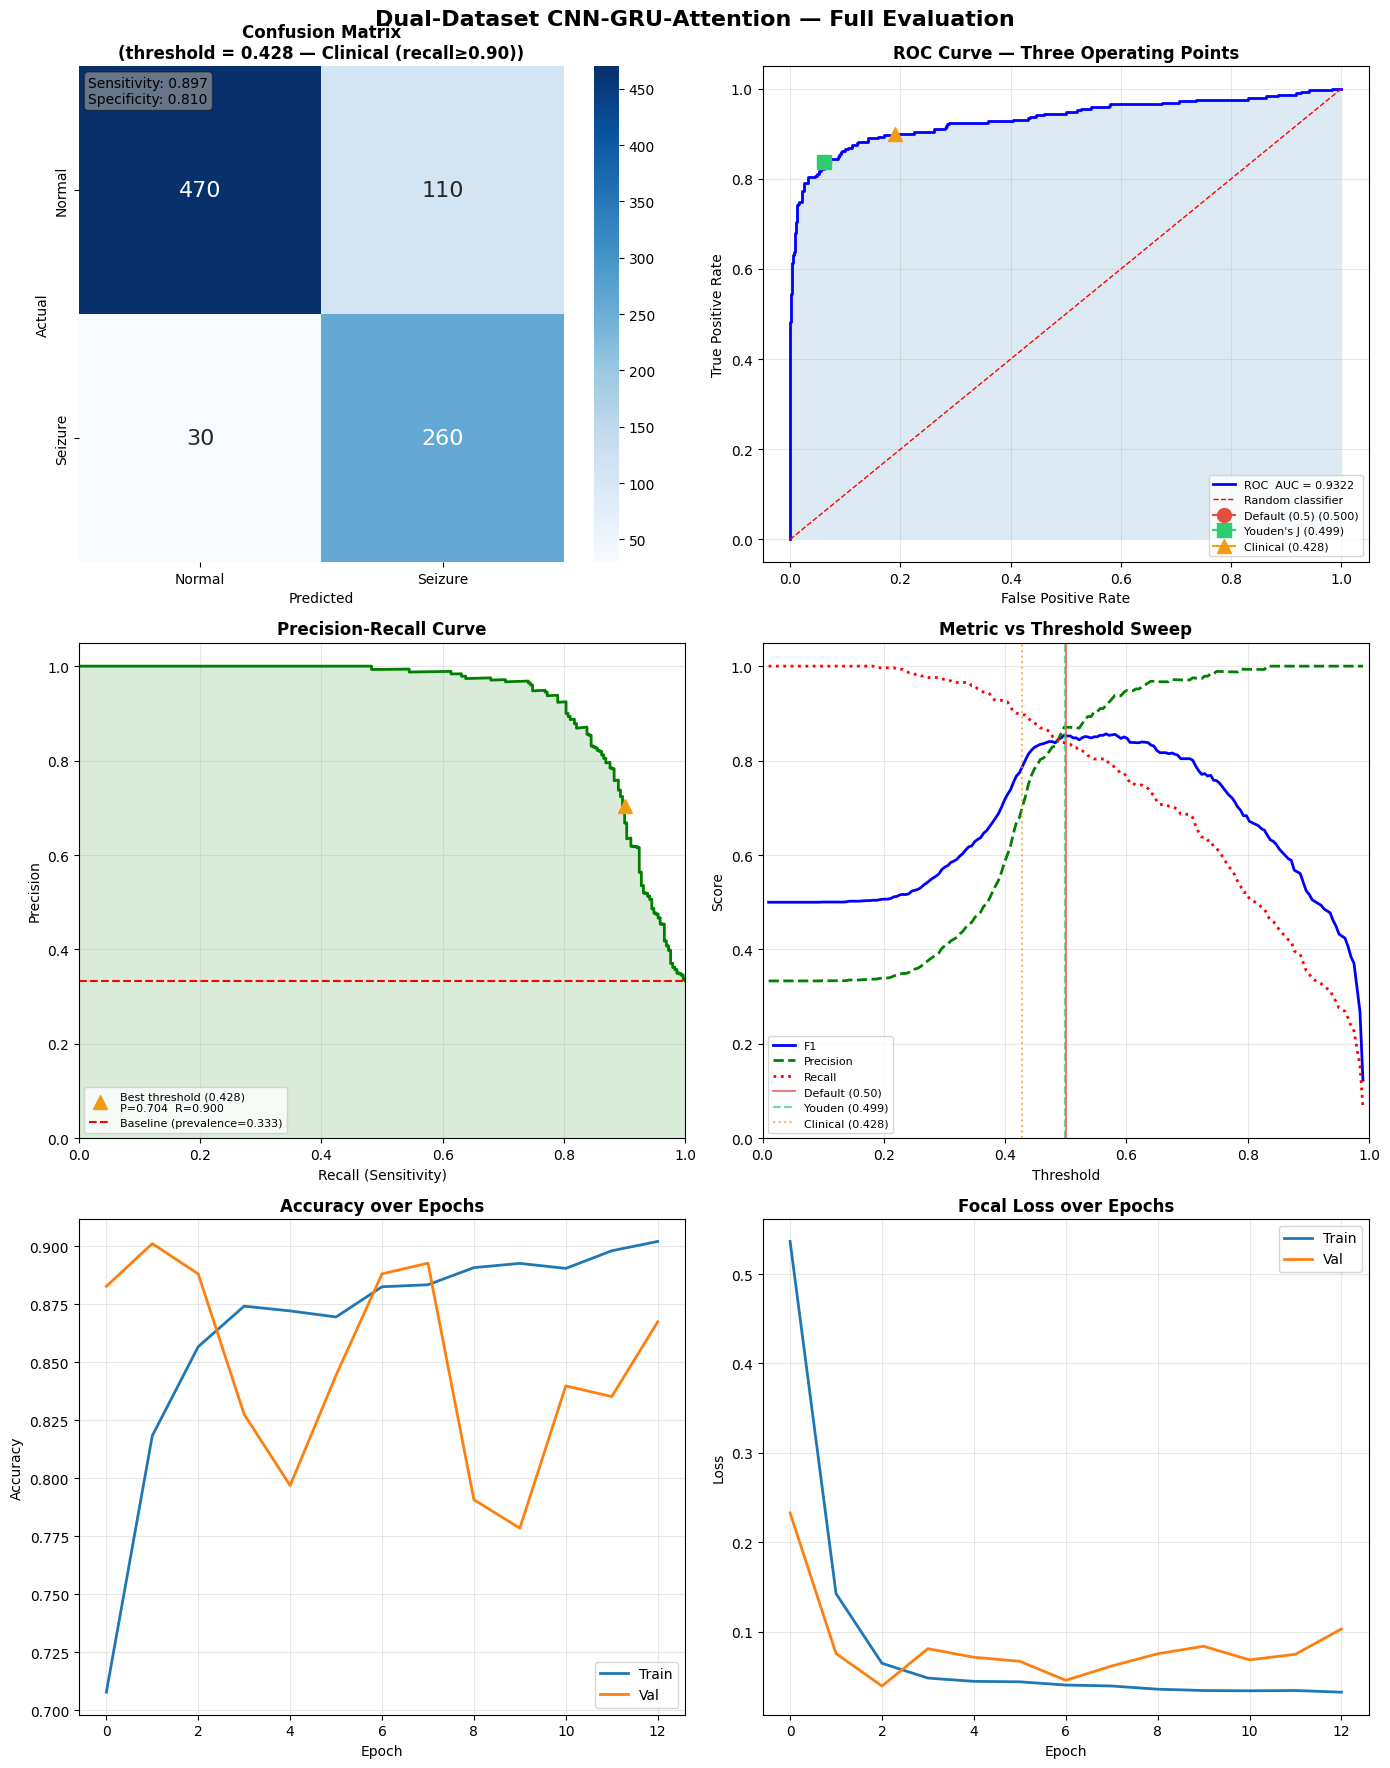

✅ Saved: training_results_v3.png


In [13]:
# ============================================================
# CELL 13: Visualize Results (UPDATED)
# Changes:
#   - 3×2 grid instead of 2×2
#   - Confusion matrix shown at BEST_THRESHOLD (not hardcoded 0.5)
#   - ROC curve annotates all three operating points
#   - New: Precision-Recall curve (more informative under imbalance)
#   - New: Threshold sweep — F1, Recall, Precision vs threshold
#   - Training curves unchanged
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

y_pred_best    = (y_pred_proba > BEST_THRESHOLD).astype(int)
y_pred_default = (y_pred_proba > THRESHOLD_DEFAULT).astype(int)
y_pred_youden  = (y_pred_proba > THRESHOLD_YOUDEN).astype(int)

# ── (0,0) Confusion matrix at BEST_THRESHOLD ─────────────────
ax = axes[0, 0]
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Seizure'],
            yticklabels=['Normal', 'Seizure'],
            annot_kws={'size': 16}, ax=ax)
ax.set_title(f'Confusion Matrix\n(threshold = {BEST_THRESHOLD:.3f} — {BEST_RESULTS["label"]})',
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Annotate TP/TN/FP/FN counts explicitly
tn_b, fp_b, fn_b, tp_b = cm_best.ravel()
ax.text(0.02, 0.98,
        f'Sensitivity: {tp_b/(tp_b+fn_b):.3f}\nSpecificity: {tn_b/(tn_b+fp_b):.3f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# ── (0,1) ROC curve with all three operating points ───────────
ax = axes[0, 1]
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC  AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.15)

# Mark three operating points
ops = [
    (r_default, 'o', '#e74c3c', 'Default (0.5)'),
    (r_youden,  's', '#2ecc71', "Youden's J"),
    (r_clin,    '^', '#f39c12', 'Clinical'),
]
for r, marker, color, lbl in ops:
    idx = np.argmin(np.abs(roc_thresholds - r['threshold']))
    ax.plot(fpr[idx], tpr[idx], marker=marker, color=color,
            markersize=10, label=f'{lbl} ({r["threshold"]:.3f})', zorder=5)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Three Operating Points', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# ── (1,0) Precision-Recall curve ─────────────────────────────
ax = axes[1, 0]
ax.plot(recalls, precisions, 'g-', linewidth=2)
ax.fill_between(recalls, precisions, alpha=0.15, color='green')

# Mark best threshold on PR curve
pr_idx = np.argmin(np.abs(pr_thresholds - BEST_THRESHOLD))
ax.plot(recalls[pr_idx], precisions[pr_idx],
        '^', color='#f39c12', markersize=10,
        label=f'Best threshold ({BEST_THRESHOLD:.3f})\n'
              f'P={precisions[pr_idx]:.3f}  R={recalls[pr_idx]:.3f}',
        zorder=5)

# Baseline (random classifier at class ratio)
baseline = np.mean(y_test)
ax.axhline(y=baseline, color='r', linestyle='--',
           label=f'Baseline (prevalence={baseline:.3f})')

ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# ── (1,1) Threshold sweep — Precision / Recall / F1 vs threshold
ax = axes[1, 1]
sweep_thresholds = np.linspace(0.01, 0.99, 200)
sweep_f1   = []
sweep_prec = []
sweep_rec  = []
for thr in sweep_thresholds:
    yp = (y_pred_proba > thr).astype(int)
    sweep_f1.append(f1_score(y_test, yp, zero_division=0))
    sweep_prec.append(precision_score(y_test, yp, zero_division=0))
    sweep_rec.append(recall_score(y_test, yp, zero_division=0))

ax.plot(sweep_thresholds, sweep_f1,   'b-',  linewidth=2, label='F1')
ax.plot(sweep_thresholds, sweep_prec, 'g--', linewidth=2, label='Precision')
ax.plot(sweep_thresholds, sweep_rec,  'r:',  linewidth=2, label='Recall')

ax.axvline(x=THRESHOLD_DEFAULT, color='#e74c3c', linestyle='-',  alpha=0.7,
           label=f'Default ({THRESHOLD_DEFAULT:.2f})')
ax.axvline(x=THRESHOLD_YOUDEN,  color='#2ecc71', linestyle='--', alpha=0.7,
           label=f"Youden ({THRESHOLD_YOUDEN:.3f})")
ax.axvline(x=THRESHOLD_CLIN,    color='#f39c12', linestyle=':',  alpha=0.7,
           label=f'Clinical ({THRESHOLD_CLIN:.3f})')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metric vs Threshold Sweep', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# ── (2,0) Training accuracy ───────────────────────────────────
ax = axes[2, 0]
ax.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
ax.set_title('Accuracy over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# ── (2,1) Training loss ───────────────────────────────────────
ax = axes[2, 1]
ax.plot(history.history['loss'],     label='Train', linewidth=2)
ax.plot(history.history['val_loss'], label='Val',   linewidth=2)
ax.set_title('Focal Loss over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Dual-Dataset CNN-GRU-Attention — Full Evaluation',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images', 'training_results_v3.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_results_v3.png')

In [14]:
# ============================================================
# CELL 14: Save Keras Weights
# ============================================================

KERAS_WEIGHTS = os.path.join(OUTPUT_DIR, 'seizure_detector.weights.h5')
KERAS_MODEL   = os.path.join(OUTPUT_DIR, 'seizure_detector_model.keras')

model.save_weights(KERAS_WEIGHTS)
model.save(KERAS_MODEL)

print(f'✅ Keras weights : {KERAS_WEIGHTS}')
print(f'✅ Keras model   : {KERAS_MODEL}')

✅ Keras weights : /kaggle/working/seizure_detector.weights.h5
✅ Keras model   : /kaggle/working/seizure_detector_model.keras


In [19]:
# ============================================================
# CELL A: Theoretical Complexity Summary
# ============================================================

print("=" * 65)
print("MODEL COMPLEXITY ANALYSIS")
print("=" * 65)

components = [
    ("Conv1D (x3)",          "O(T * C_in * C_out * K)", "K=kernel size, T=timesteps"),
    ("MaxPooling (x3)",      "O(T * C)",                "Reduces T by 2x each layer"),
    ("GRU (x2)",             "O(T * H^2)",              "H=128 then 64 hidden units"),
    ("MultiHeadAttention",   "O(T^2 * d)",              "T~128 after pooling, d=32"),
    ("Dense + Output",       "O(d_in * d_out)",         "Negligible cost"),
]

print(f"\n  {'Component':<24} {'Time Complexity':<22} {'Notes'}")
print("  " + "-" * 62)
for name, complexity, note in components:
    print(f"  {name:<24} {complexity:<22} {note}")

print("\n  Dominant costs:")
print("    - GRU        : O(T * H^2) -- main training bottleneck")
print("    - Attention  : O(T^2 * d) -- main inference bottleneck")
print("    - T ~ 128 after 3x max-pooling (from 1024 original samples)")

print("\n  Preprocessing per window:")
steps = [
    ("Bandpass filter",  "O(T)"),
    ("Notch filter",     "O(T)"),
    ("Z-score norm",     "O(C * T)"),
    ("Window sliding",   "O(N / step)  windows total"),
]
for name, complexity in steps:
    print(f"    {name:<20} {complexity}")

print("\n  Input dimensions:")
print(f"    Window samples : 1024  (4s x 256 Hz)")
print(f"    Channels       : 18")
print(f"    Sequence after pooling : 1024 / (2^3) = 128")
print("=" * 65)

MODEL COMPLEXITY ANALYSIS

  Component                Time Complexity        Notes
  --------------------------------------------------------------
  Conv1D (x3)              O(T * C_in * C_out * K) K=kernel size, T=timesteps
  MaxPooling (x3)          O(T * C)               Reduces T by 2x each layer
  GRU (x2)                 O(T * H^2)             H=128 then 64 hidden units
  MultiHeadAttention       O(T^2 * d)             T~128 after pooling, d=32
  Dense + Output           O(d_in * d_out)        Negligible cost

  Dominant costs:
    - GRU        : O(T * H^2) -- main training bottleneck
    - Attention  : O(T^2 * d) -- main inference bottleneck
    - T ~ 128 after 3x max-pooling (from 1024 original samples)

  Preprocessing per window:
    Bandpass filter      O(T)
    Notch filter         O(T)
    Z-score norm         O(C * T)
    Window sliding       O(N / step)  windows total

  Input dimensions:
    Window samples : 1024  (4s x 256 Hz)
    Channels       : 18
    Sequence afte

In [20]:
# ============================================================
# CELL A: Inference Latency Benchmark
# ============================================================
import timeit
import numpy as np

batch_sizes = [1, 8, 32, 64]
n_runs = 20
print("=" * 50)
print("⏱️  INFERENCE LATENCY BENCHMARK")
print("=" * 50)

latencies = {}
for bs in batch_sizes:
    dummy = np.random.rand(bs, X_test.shape[1], X_test.shape[2]).astype(np.float32)
    t = timeit.timeit(lambda: model.predict(dummy, verbose=0), number=n_runs) / n_runs
    latencies[bs] = t
    per_sample_ms = (t / bs) * 1000
    print(f"  Batch={bs:>3}: {t*1000:.1f} ms total | {per_sample_ms:.2f} ms/sample")

# Real-time feasibility check
window_sec = 4.0  # seconds of EEG per window
single_latency_ms = latencies[1] * 1000
print(f"\n  Window duration  : {window_sec}s = {window_sec*1000:.0f} ms")
print(f"  Single inference : {single_latency_ms:.2f} ms")
print(f"  Real-time capable: {'✅ YES' if single_latency_ms < window_sec*1000 else '❌ NO'}")

⏱️  INFERENCE LATENCY BENCHMARK
  Batch=  1: 121.1 ms total | 121.13 ms/sample
  Batch=  8: 127.6 ms total | 15.95 ms/sample
  Batch= 32: 184.3 ms total | 5.76 ms/sample
  Batch= 64: 286.2 ms total | 4.47 ms/sample

  Window duration  : 4.0s = 4000 ms
  Single inference : 121.13 ms
  Real-time capable: ✅ YES


In [22]:
# ============================================================
# CELL B: Memory & Parameter Complexity
# ============================================================
import tracemalloc

# 1. Model parameter count
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print("=" * 50)
print("💾 MODEL COMPLEXITY SUMMARY")
print("=" * 50)
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Approx model size    : {total_params * 4 / 1024**2:.2f} MB (float32)")

# 2. Peak memory during inference
tracemalloc.start()
_ = model.predict(X_test[:32], verbose=0)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"\n  Inference peak RAM   : {peak / 1024**2:.2f} MB  (batch=32)")

# 3. Dataset memory
print(f"\n  X_train size         : {X_train.nbytes / 1024**2:.1f} MB")
print(f"  X_val size           : {X_val.nbytes / 1024**2:.1f} MB")
print(f"  X_test size          : {X_test.nbytes / 1024**2:.1f} MB")

💾 MODEL COMPLEXITY SUMMARY
  Total parameters     : 220,257
  Trainable parameters : 219,681
  Approx model size    : 0.84 MB (float32)

  Inference peak RAM   : 2.36 MB  (batch=32)

  X_train size         : 648.4 MB
  X_val size           : 91.8 MB
  X_test size          : 61.2 MB


  n=   50: 272.4 ms
  n=  100: 435.1 ms
  n=  200: 755.0 ms
  n=  500: 1734.0 ms
  n= 1000: 3482.4 ms
  n= 2000: 6668.7 ms


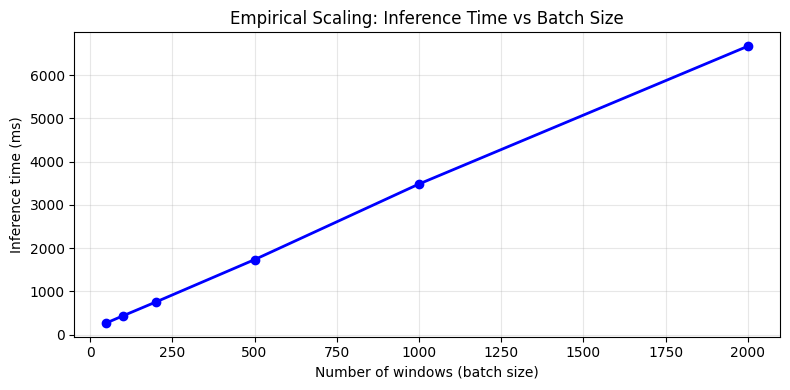

In [23]:
# ============================================================
# CELL C: Empirical Scaling — Time vs Input Size
# ============================================================
import matplotlib.pyplot as plt
import timeit

sample_sizes = [50, 100, 200, 500, 1000, 2000]
times = []

for n in sample_sizes:
    dummy = np.random.rand(n, X_test.shape[1], X_test.shape[2]).astype(np.float32)
    t = timeit.timeit(lambda: model.predict(dummy, verbose=0), number=5) / 5
    times.append(t * 1000)
    print(f"  n={n:>5}: {t*1000:.1f} ms")

plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, times, 'bo-', linewidth=2, markersize=6)
plt.xlabel("Number of windows (batch size)")
plt.ylabel("Inference time (ms)")
plt.title("Empirical Scaling: Inference Time vs Batch Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images', 'complexity_scaling.png'), dpi=150)
plt.show()

In [24]:
# ============================================================
# CELL: FLOPs Counter
# ============================================================
import numpy as np

T  = 1024   # timesteps (window samples)
C  = 18     # input channels
H1 = 128    # GRU hidden units layer 1
H2 = 64     # GRU hidden units layer 2
num_heads = 4
key_dim   = 32

# After 3x MaxPooling(2), sequence length becomes:
T1 = T  // 2        # 512  after pool 1
T2 = T1 // 2        # 256  after pool 2
T3 = T2 // 2        # 128  after pool 3 (input to GRU)

print("=" * 55)
print("FLOPs BREAKDOWN (per single inference window)")
print("=" * 55)

# ── CNN Layers ───────────────────────────────────────────────
# FLOPs per Conv1D = 2 * T * C_in * C_out * K
conv1 = 2 * T  * C  * 32  * 7
conv2 = 2 * T1 * 32 * 64  * 5
conv3 = 2 * T2 * 64 * 128 * 3

print(f"\n  [CNN]")
print(f"  Conv1D-1 (C=18->32,  K=7) : {conv1:>12,.0f}")
print(f"  Conv1D-2 (C=32->64,  K=5) : {conv2:>12,.0f}")
print(f"  Conv1D-3 (C=64->128, K=3) : {conv3:>12,.0f}")
cnn_total = conv1 + conv2 + conv3
print(f"  CNN Total                  : {cnn_total:>12,.0f}")

# ── GRU Layers ───────────────────────────────────────────────
# FLOPs per GRU = T * (3 gates) * 2 * (C_in * H + H * H)
gru1 = T3 * 3 * 2 * (128 * H1 + H1 * H1)
gru2 = T3 * 3 * 2 * (H1  * H2 + H2 * H2)

print(f"\n  [GRU]")
print(f"  GRU-1 (128->128, T=128)    : {gru1:>12,.0f}")
print(f"  GRU-2 (128->64,  T=128)    : {gru2:>12,.0f}")
gru_total = gru1 + gru2
print(f"  GRU Total                  : {gru_total:>12,.0f}")

# ── Attention Layer ──────────────────────────────────────────
# FLOPs = 2 * num_heads * T^2 * key_dim  (QK^T + softmax*V)
attn = 2 * num_heads * (T3 ** 2) * key_dim

print(f"\n  [Multi-Head Attention]")
print(f"  Heads={num_heads}, T={T3}, key_dim={key_dim}")
print(f"  Attention                  : {attn:>12,.0f}")

# ── Dense Layers ─────────────────────────────────────────────
# Input to dense = GlobalAvgPool + GlobalMaxPool = 2 * 128 = 256
dense_input = 2 * 128
dense1 = 2 * dense_input * 64
dense2 = 2 * 64 * 32
dense3 = 2 * 32 * 1
dense_total = dense1 + dense2 + dense3

print(f"\n  [Dense Classifier]")
print(f"  Dense-1 (256->64)          : {dense1:>12,.0f}")
print(f"  Dense-2 (64->32)           : {dense2:>12,.0f}")
print(f"  Dense-3 (32->1)            : {dense3:>12,.0f}")
print(f"  Dense Total                : {dense_total:>12,.0f}")

# ── Grand Total ──────────────────────────────────────────────
total = cnn_total + gru_total + attn + dense_total
print(f"\n{'=' * 55}")
print(f"  TOTAL FLOPs (1 window)     : {total:>12,.0f}")
print(f"  TOTAL MFLOPs               : {total/1e6:>11.2f} M")
print(f"  TOTAL GFLOPs               : {total/1e9:>11.4f} G")

# ── Real-time cost ───────────────────────────────────────────
fs         = 256
window_sec = 4.0
step_sec   = 2.0   # 50% overlap -> new window every 2s
windows_per_min = 60 / step_sec

print(f"\n  [Real-Time Cost Estimate]")
print(f"  New window every           : {step_sec}s (50% overlap)")
print(f"  Windows per minute         : {windows_per_min:.0f}")
print(f"  MFLOPs per minute          : {total/1e6 * windows_per_min:,.1f} M")
print(f"  GFLOPs per minute          : {total/1e9 * windows_per_min:.4f} G")
print("=" * 55)

FLOPs BREAKDOWN (per single inference window)

  [CNN]
  Conv1D-1 (C=18->32,  K=7) :    8,257,536
  Conv1D-2 (C=32->64,  K=5) :   10,485,760
  Conv1D-3 (C=64->128, K=3) :   12,582,912
  CNN Total                  :   31,326,208

  [GRU]
  GRU-1 (128->128, T=128)    :   25,165,824
  GRU-2 (128->64,  T=128)    :    9,437,184
  GRU Total                  :   34,603,008

  [Multi-Head Attention]
  Heads=4, T=128, key_dim=32
  Attention                  :    4,194,304

  [Dense Classifier]
  Dense-1 (256->64)          :       32,768
  Dense-2 (64->32)           :        4,096
  Dense-3 (32->1)            :           64
  Dense Total                :       36,928

  TOTAL FLOPs (1 window)     :   70,160,448
  TOTAL MFLOPs               :       70.16 M
  TOTAL GFLOPs               :      0.0702 G

  [Real-Time Cost Estimate]
  New window every           : 2.0s (50% overlap)
  Windows per minute         : 30
  MFLOPs per minute          : 2,104.8 M
  GFLOPs per minute          : 2.1048 G
